In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from huggingface_hub import login
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from vllm import LLM, SamplingParams
import optuna

import mlflow
from databricks.sdk import WorkspaceClient

/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-12-07 19:04:30.296871: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-07 19:04:30.314289: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-07 19:04:30.321478: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-07 19:04:30.366264: I tensorflow/core/platfor

INFO 12-07 19:04:32 [__init__.py:239] Automatically detected platform cuda.


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [4]:
model_id = "allenai/longformer-base-4096"
model_name = "longformer-base-4096"
classification_type = "pairwise_contrastive_embedding_with_fine-tuning"

developer_initials = "JP"

In [5]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "transformer"

train_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-training-large-cleaned.jsonl"
validation_data_full_cleaned_path = current_dir.parent.parent / "data" / "01_processed" / "pan20-authorship-verification-validation-large-cleaned.jsonl"
test_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan21-authorship-verification-test-cleaned.jsonl"

run_name=f"{developer_initials}_{model_name}_{results_path}_{classification_type}"
finetuned_model_weights_path = current_dir.parent.parent / "data" / "02_models" / f"{run_name}_best_weights.bin"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / f"{run_name}_best_model"

Load environment variables
Get access to HuggingFace

In [6]:
load_dotenv(env_path)
huggingface_acess_token = os.getenv("huggingface_jp")

Connect to databricks for logging results

In [7]:
w = WorkspaceClient()   
print("Connected to:", w.config.host)

mlflow.set_tracking_uri("databricks")
mlflow.autolog()

2025/12/07 19:04:34 INFO mlflow.tracking.fluent: Autologging successfully enabled for keras.


Connected to: https://dbc-1ea3ad0e-f504.cloud.databricks.com


2025/12/07 19:04:35 INFO mlflow.tracking.fluent: Autologging successfully enabled for openai.
2025/12/07 19:04:35 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.4.0 <= scikit-learn, but the installed version is 1.3.1. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2025/12/07 19:04:35 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/12/07 19:04:35 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.14.1 <= statsmodels, but the installed version is 0.14.0. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.
2025/12/07 19:04:35 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/12/07 19:04:35 WARNING mlflow.tracking.fluent: Exception raised while enabling 

What are GPU are the experiments run on

In [8]:
!nvidia-smi

Sun Dec  7 19:04:36 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          Off |   00000000:61:00.0 Off |                    0 |
| N/A   51C    P0             48W /  300W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [9]:
running_on_gpu = torch.cuda.is_available()
device = torch.device("cuda" if running_on_gpu else "cpu")

In [10]:
if running_on_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)
else:
    gpu_name = "CPU"
    gpu_props = "N/A"
    gpu_vram_gb = 0

Empty the GPU from previous experiments

In [11]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

111

In [12]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Definition of the training constants

In [13]:
cosine_embedding_loss_margin_range = (0.1, 0.5)
optimizer_learning_rate_range = (1e-5, 5e-5)
epochs_range = (2, 5)
batch_size = [2]
classification_thresholds = [x/1000 for x in range(500, 999)]

# Load dataset

#### Load training data

In [14]:
train_data_file_size = os.path.getsize(train_data_full_cleaned_path)
train_data = []

with open(train_data_full_cleaned_path, 'r') as f:
    with tqdm(total=train_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            train_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(train_data)} items.")

Loading data: 100%|██████████| 11.4G/11.4G [01:01<00:00, 186MB/s] 


Successfully loaded 275801 items.


In [15]:
train_data_df = pd.DataFrame(train_data)
train_data_df = train_data_df.head(10)

Prepare dataset for cosine embedding loss

In [16]:
train_data_df["same"] = train_data_df["same"].apply(lambda x: 1 if x == 1 else -1)

#### Load validation data

In [17]:
val_data_file_size = os.path.getsize(validation_data_full_cleaned_path)
val_data = []

with open(validation_data_full_cleaned_path, 'r') as f:
    with tqdm(total=val_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            val_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(val_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:04<00:00, 198MB/s] 


Successfully loaded 19999 items.


In [18]:
val_data_df = pd.DataFrame(val_data)
val_data_df = val_data_df.head(10)

Prepare dataset for cosine embedding loss

In [19]:
val_data_df["same"] = val_data_df["same"].apply(lambda x: 1 if x == 1 else -1)

#### Load testing data

In [20]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:04<00:00, 192MB/s] 


Successfully loaded 19999 items.


In [21]:
test_data_df = pd.DataFrame(test_data)
test_data_df = test_data_df.head(10)

# Set up model

Log in to huggingface

In [22]:
login(huggingface_acess_token)

Load the pre-trained model

In [23]:
tokenizer = AutoTokenizer.from_pretrained(model_id)

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# Set up training functions

Helper class for pytorch

In [24]:
class PairDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text1 = row["pair"][0]
        text2 = row["pair"][1]
        label = int(row["same"])
        return text1, text2, label

Function to build embeddings

In [25]:
def get_embedding(model, text: str):
        encoded = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            padding= False,
            max_length=4096,
        ).to(device)
        
        with torch.no_grad():
            output = model(**encoded)
            cls_emb = output.last_hidden_state[:, 0, :]
            embedding = F.normalize(cls_emb, p=2, dim=1)
        return embedding.cpu()

Model training function

In [26]:
def train_contrastive(model, df, criterion, optimizer, epochs=1, batch_size=2, trial=None):

    ds = PairDataset(df)
    dataloader = DataLoader(ds, shuffle=True, batch_size=batch_size)

    model.train()
    
    if trial is not None:
        print(f"Starting optuna trial #{trial.number + 1} 🐻")
        
    for epoch in range(epochs):
        total_loss = 0

        for text1, text2, targets in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):

            enc1 = tokenizer(
                list(text1), return_tensors="pt", padding=True,
                truncation=True, max_length=4096
            ).to(device)
            enc2 = tokenizer(
                list(text2), return_tensors="pt", padding=True,
                truncation=True, max_length=4096
            ).to(device)

            out1 = model(**enc1).last_hidden_state[:,0,:]
            out2 = model(**enc2).last_hidden_state[:,0,:]

            emb1 = F.normalize(out1, p=2, dim=1)
            emb2 = F.normalize(out2, p=2, dim=1)

            targets = targets.to(device).float()

            loss = criterion(emb1, emb2, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            avg_loss = total_loss / len(dataloader)

        if trial is not None:
            print(f"Optuna trial #{trial.number + 1} Epoch {epoch+1}/{epochs} complete | Loss: {avg_loss:.4f}")
        else:
            print(f"Epoch {epoch+1}/{epochs} complete | Loss: {avg_loss:.4f}")

   
    return model

# Set up evaluation functions

Evaluate model function

In [27]:
def compute_similarities(test_data_df, model):
    start_time = time.time()
    verification_results = []
    model.eval()
    for i in tqdm(test_data_df.index, desc="Computing similarities"):
        resulting_df_row = {}
        resulting_df_row['id']  = test_data_df.loc[i, 'id']
        resulting_df_row['actual_result'] = test_data_df.loc[i, 'same']
        text1 = test_data_df.loc[i, 'pair'][0]
        text2 = test_data_df.loc[i, 'pair'][1]
        
        text1_embedding = get_embedding(model, text1)
        text2_embedding = get_embedding(model, text2)

        cosine_similarity_score = cosine_similarity(text1_embedding, text2_embedding)

        sim_torch = F.cosine_similarity(text1_embedding, text2_embedding).item()        
        resulting_df_row['cosine_similarity'] = cosine_similarity_score
        verification_results.append(resulting_df_row)

    result_df = pd.DataFrame(verification_results)
    print("--- Execution Time: %s seconds ---" % round(time.time() - start_time, 2))

    return result_df

Evaluation function

In [28]:
def evaluate_results(y_true, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_true, y_pred)*100, 2)
    precision = round(precision_score(y_true, y_pred, average=average)*100, 2)
    recall = round(recall_score(y_true, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_true, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Optimal threshold search

In [29]:
def evaluate_classification_thresholds(result_df, classification_thresholds):
    results = []
    y_embeddings = result_df['cosine_similarity']
    y_true = result_df['actual_result']
    for threshold in classification_thresholds:
        y_pred = (result_df["cosine_similarity"] >= threshold).astype(int)
        accuracy, precision, recall, f1 = evaluate_results(y_true, y_pred)
        results.append({
            "threshold": threshold,
            "accuracy" : accuracy,
            "precision" : precision,
            "recall" : recall,
            "f1" : f1
        })
    return pd.DataFrame(results)

Create histogram of F1 score for different thresholds

In [30]:
def plot_f1_vs_threshold(results_df):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["threshold"], results_df["f1"], linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Classification Threshold")
    plt.grid(True)
    plt.tight_layout()
    return plt.gcf()

Create the confusion matrix

In [31]:
def create_confusion_matrix(y_true, y_pred, labels=[False, True]):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    cm_fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, 
                fmt='d', 
                cmap='Blues',
                xticklabels=labels, 
                yticklabels=labels, 
                ax=ax,
                cbar=False)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix: {model_id}')
    return cm_fig

Objective function - to train and evaluate all combinations of the model and log the results

In [32]:
def objective(trial):
    top_f1_trial = -1
    
    margin = trial.suggest_float("margin", cosine_embedding_loss_margin_range[0], cosine_embedding_loss_margin_range[1])
    lr = trial.suggest_float("lr", optimizer_learning_rate_range[0], optimizer_learning_rate_range[1], log=True)
    epochs = trial.suggest_int("epochs", epochs_range[0], epochs_range[1])
    batch_s = trial.suggest_categorical("batch_size", batch_size)

    model = AutoModel.from_pretrained(model_id)
    model = model.to(device)
    
    criterion = nn.CosineEmbeddingLoss(margin=margin)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    trained_model = train_contrastive(
        model=model,
        df=train_data_df,
        criterion=criterion,
        optimizer=optimizer,
        epochs=epochs,
        batch_size=batch_s,
        trial=trial
    )
    print(f"Training for the optuna trial complete --- computing similarities  \n")

    result_df = compute_similarities(test_data_df, model)
    print(f"Training for the optuna trial complete --- evaluating thresholds  \n")

    threshold_results_df = evaluate_classification_thresholds(result_df, classification_thresholds)

    f1_threshold_histogram_fig = plot_f1_vs_threshold(threshold_results_df)
    
    top_row = threshold_results_df.sort_values("f1", ascending=False).iloc[0]
    top_threshold = top_row["threshold"]
    top_f1 = top_row["f1"]
    top_accuracy = top_row["accuracy"]
    top_precision = top_row["precision"]
    top_recall = top_row["recall"]

    y_true = result_df["actual_result"]
    y_pred = (result_df["cosine_similarity"] >= top_threshold).astype(int)
    cm_fig = create_confusion_matrix(y_true, y_pred)

    print(f"Training for the optuna trial complete --- logging results  \n")
    date_str = datetime.now().strftime("%Y%m%d_%H%M")
    mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
    with mlflow.start_run(run_name=f"{developer_initials}_{model_name}_results_{classification_type}_{trial.number}"):
        mlflow.log_param("gpu_name", gpu_name)
        mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
        
        mlflow.log_param("model_id ", model_id )
        mlflow.log_param("classification_type", classification_type)
        mlflow.log_param("cosine_embedding_loss_margin", margin)
        mlflow.log_param("optimizer_learning_rate", lr)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("batch_size", batch_size)
        
        mlflow.log_param("classification_thresholds", classification_thresholds)
        mlflow.log_table(data=result_df, artifact_file="embedding_similarity_results.json")
        mlflow.log_table(data=threshold_results_df, artifact_file="results_for_different_thresholds.json")

        mlflow.log_metric("top_threshold", top_threshold)
        mlflow.log_metric("top_result_accuracy", top_accuracy)
        mlflow.log_metric("top_precision", top_precision)
        mlflow.log_metric("top_recall", top_recall)
        mlflow.log_metric("top_f1", top_f1)
    
        mlflow.log_figure(f1_threshold_histogram_fig, "f1_results_threshold_histogram.png")
        mlflow.log_figure(cm_fig, "confusion_matrix.png")

    if top_f1 > top_f1_trial:
        top_f1_trial = top_f1
        top_state = model.state_dict()
        trial.set_user_attr("model_state_dict", model.state_dict())

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return top_f1

Log model information + metrics + results table + confusion matrix

[I 2025-12-07 19:05:48,899] A new study created in memory with name: no-name-f52ce181-af1f-4a94-a3bb-23d93bf09111


pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

Starting optuna trial #1 🐻


Epoch 1/2:   0%|          | 0/5 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

...

Epoch 2/2: 100%|██████████| 5/5 [00:06<00:00,  1.35s/it]


Optuna trial #1 Epoch 2/2 complete | Loss: 0.0137
Training for the optuna trial complete --- computing similarities  



Computing similarities: 100%|██████████| 10/10 [00:01<00:00,  5.61it/s]


--- Execution Time: 1.79 seconds ---
Training for the optuna trial complete --- evaluating thresholds  

Training for the optuna trial complete --- logging results  

🏃 View run JP_longformer-base-4096_results_pairwise_contrastive_embedding_with_fine-tuning_0 at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/24494fa2811d4fa5a6697fb02576fe02
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


[I 2025-12-07 19:06:21,226] Trial 0 finished with value: 82.35 and parameters: {'margin': 0.4587479944106003, 'lr': 2.0496530518713305e-05, 'epochs': 2, 'batch_size': 2}. Best is trial 0 with value: 82.35.


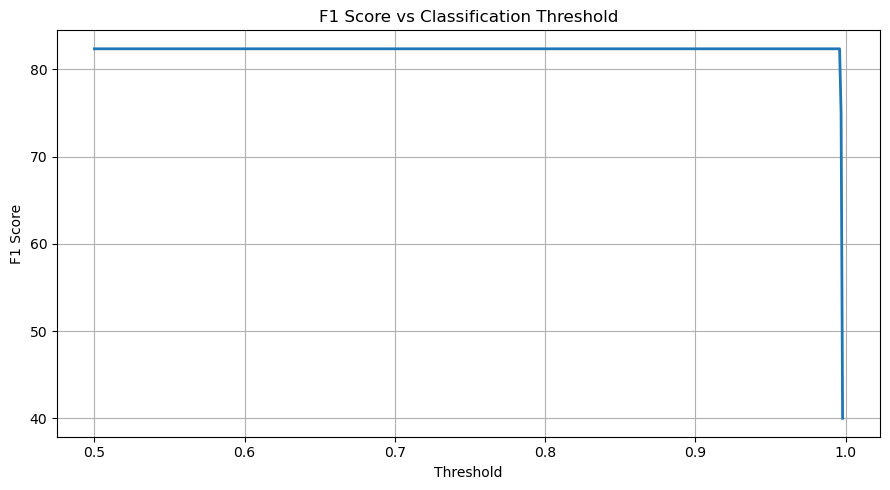

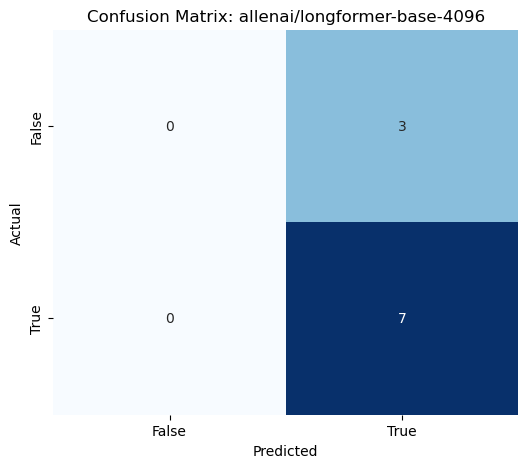

In [33]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=1)

Save the best model

In [34]:
best_trial = study.best_trial
best_state_dict = best_trial.user_attrs["model_state_dict"]

model = AutoModel.from_pretrained(model_id)
model.load_state_dict(best_state_dict)

model.save_pretrained(finetuned_model_path)